Stage 1: Installing Ollama and Pull Model

In [1]:
# Stage 1a-prep: Install zstd (required by the Ollama installer)
!apt-get install -y zstd -q

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 67 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (554 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
# Stage 1a: Install Ollama in the Colab runtime
!curl -fsSL https://ollama.com/install.sh | sh
print('Ollama installed.')

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama installed.


In [3]:
# Stage 1b: Start Ollama server in the background and pull Mistral
import subprocess, time

# Start server as background process
proc = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)  # wait for server to start

# Pull the model
!ollama pull mistral
print('\nMistral 7B ready.')



Mistral 7B ready.


In [4]:
# Stage 1c: Verify Ollama is running
import requests

try:
    r = requests.get('http://localhost:11434/api/tags', timeout=10)
    models = [m['name'] for m in r.json().get('models', [])]
    print(f'Ollama is running. Available models: {models}')
except Exception as e:
    print(f'Ollama not responding: {e}')
    print('Try re-running Stage 1b.')

Ollama is running. Available models: ['mistral:latest']


In [5]:
# Stage 1d: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('Libraries loaded.')

Libraries loaded.


Stage 2: Load Test Data and Few-shot Examples

In [6]:
# Stage 2a: Upload test.csv and train.csv (train is needed for few-shot examples only)
from google.colab import files
print('Upload test.csv and train.csv when prompted.')
uploaded = files.upload()

Upload test.csv and train.csv when prompted.


Saving test.csv to test.csv
Saving train.csv to train.csv


In [7]:
# Stage 2b: Load data
test_df  = pd.read_csv('test.csv')
train_df = pd.read_csv('train.csv')

# Drop any NaN sentence_text
test_df  = test_df.dropna(subset=['sentence_text']).reset_index(drop=True)
train_df = train_df.dropna(subset=['sentence_text']).reset_index(drop=True)

y_test = test_df['label'].values

print(f'Test set : {len(test_df)} sentences')
print(f'Train set: {len(train_df)} sentences (for few-shot example selection only)')
print(f'Test balance: {test_df["label_text"].value_counts().to_dict()}')

Test set : 597 sentences
Train set: 2254 sentences (for few-shot example selection only)
Test balance: {'NON_COMPLIANT': 311, 'COMPLIANT': 286}


In [8]:
# Stage 2c: Select few-shot examples from training set
# Pick balanced, clear examples — one compliant and one non-compliant per selection
# Use SEED sentences only (clearest, most grounded) for few-shot examples

seed_examples = train_df[train_df['source'].isin(['ce_definition', 'dspt_definition', 'cqc_style'])].copy()

# If no source column or no seeds in train, fall back to shortest/clearest sentences
if len(seed_examples) < 10:
    seed_examples = train_df.copy()
    seed_examples['word_count'] = seed_examples['sentence_text'].str.split().str.len()
    seed_examples = seed_examples[seed_examples['word_count'].between(8, 20)]

# Select 3 compliant + 3 non-compliant (for 3-shot and 5-shot)
comp_examples   = seed_examples[seed_examples['label'] == 1].sample(n=3, random_state=42)
nc_examples     = seed_examples[seed_examples['label'] == 0].sample(n=3, random_state=42)
few_shot_pool   = pd.concat([comp_examples, nc_examples]).sample(frac=1, random_state=42)

print('Few-shot example pool (6 examples):')
for r in few_shot_pool.itertuples():
    print(f'  [{r.label_text:14s}] {r.sentence_text}')

Few-shot example pool (6 examples):
  [COMPLIANT     ] The registered manager holds overall accountability for data protection.
  [COMPLIANT     ] Our training matrix shows all staff are up to date on data security.
  [NON_COMPLIANT ] Electronic care records are not backed up at all.
  [COMPLIANT     ] Care assistants can view care plans but cannot access payroll information.
  [NON_COMPLIANT ] There is no firewall protecting the home's network from the internet.
  [NON_COMPLIANT ] The home uses an operating system that no longer receives security updates.


Stage 3: Define Prompts

In [9]:
# Stage 3: Prompt templates

SYSTEM_CONTEXT = """You are an expert UK care home cybersecurity compliance assessor.

Your task is to classify a statement from a care home document as either COMPLIANT or NON_COMPLIANT based on the following regulatory frameworks:

CYBER ESSENTIALS (5 controls):
- CE1 Firewalls: boundary firewall configured, default passwords changed, inbound blocked by default
- CE2 Secure Configuration: defaults changed, unnecessary software removed, unused accounts disabled
- CE3 Patching: critical updates within 14 days, automatic updates enabled, no unsupported software
- CE4 Access Control: MFA on remote access, least privilege, separate admin accounts, leavers removed
- CE5 Malware Protection: anti-malware active and updated on all devices, email/web filtering

DSPT / NDG STANDARDS (10 standards):
- DSPT1: staff understand data handling responsibilities
- DSPT2: data responsibilities in contracts, breaches acted upon
- DSPT3: annual data security training completed, tested, recorded
- DSPT4: role-based access, access removed when no longer needed
- DSPT5: processes reviewed annually, lessons learned from incidents
- DSPT6: incident response procedure documented, breaches reported to ICO within 72 hours
- DSPT7: business continuity plan, backups taken and tested
- DSPT8: no unsupported systems in use
- DSPT9: data encrypted, cyber strategy based on recognised framework, DSPT submitted
- DSPT10: data processing agreements with all suppliers

RULES:
- A statement is COMPLIANT if it describes a practice that MEETS a control requirement.
- A statement is NON_COMPLIANT if it describes a practice that FAILS to meet a control requirement.
- Focus on what the statement SAYS IS HAPPENING, not what should happen.
- Negation words (no, not, without, never, lack) typically indicate non-compliance.
- Respond with ONLY a JSON object: {"label": "COMPLIANT" or "NON_COMPLIANT", "control": "<control code>", "reason": "<one sentence>"}
- Do NOT add any text before or after the JSON object."""


def build_zero_shot_prompt(sentence):
    return f"""{SYSTEM_CONTEXT}

Statement: \"{sentence}\"

Classify this statement."""


def build_few_shot_prompt(sentence, examples):
    example_block = ""
    for r in examples.itertuples():
        example_block += f"""\nStatement: \"{r.sentence_text}\"
Answer: {{"label": "{r.label_text}", "control": "{r.control}", "reason": "example"}}
"""
    return f"""{SYSTEM_CONTEXT}

Here are some examples:
{example_block}
Now classify this new statement:

Statement: \"{sentence}\"

Classify this statement."""


# Quick preview
print('=== ZERO-SHOT PROMPT PREVIEW ===')
print(build_zero_shot_prompt('Antivirus is installed on all computers.')[:500])
print('\n...')

=== ZERO-SHOT PROMPT PREVIEW ===
You are an expert UK care home cybersecurity compliance assessor.

Your task is to classify a statement from a care home document as either COMPLIANT or NON_COMPLIANT based on the following regulatory frameworks:

CYBER ESSENTIALS (5 controls):
- CE1 Firewalls: boundary firewall configured, default passwords changed, inbound blocked by default
- CE2 Secure Configuration: defaults changed, unnecessary software removed, unused accounts disabled
- CE3 Patching: critical updates within 14 days, auto

...


Stage 4: LLM Inference Engine

In [10]:
# Stage 4: Inference functions

OLLAMA_URL = 'http://localhost:11434/api/generate'

def call_ollama(prompt, model='mistral', timeout=120, retries=2):
    """Send a prompt to Ollama and return the raw text response."""
    for attempt in range(retries + 1):
        try:
            r = requests.post(
                OLLAMA_URL,
                json={
                    'model': model,
                    'prompt': prompt,
                    'stream': False,
                    'keep_alive': '30m',
                    'options': {'temperature': 0.0, 'top_p': 0.1},  # near-deterministic
                },
                timeout=timeout,
            )
            r.raise_for_status()
            return r.json().get('response', '')
        except Exception as e:
            if attempt < retries:
                time.sleep(5)
            else:
                return f'ERROR: {e}'


def parse_response(raw):
    """Extract label and reason from LLM JSON response."""
    raw = raw.strip()
    # Strip markdown fences if present
    raw = re.sub(r'^```(?:json)?\s*', '', raw)
    raw = re.sub(r'\s*```$', '', raw)

    # Try to find a JSON object
    match = re.search(r'\{[^}]+\}', raw, re.DOTALL)
    if match:
        try:
            obj = json.loads(match.group(0))
            label_str = str(obj.get('label', '')).strip().upper()
            control = str(obj.get('control', '')).strip()
            reason  = str(obj.get('reason', '')).strip()

            # Normalise label
            if 'NON' in label_str:
                return 0, control, reason, False
            elif 'COMP' in label_str:
                return 1, control, reason, False
        except json.JSONDecodeError:
            pass

    # Fallback: look for keywords in raw text
    upper = raw.upper()
    if 'NON_COMPLIANT' in upper or 'NON-COMPLIANT' in upper or 'NONCOMPLIANT' in upper:
        return 0, '', '', False
    elif 'COMPLIANT' in upper:
        return 1, '', '', False

    # Unparseable
    return -1, '', raw[:200], True  # -1 = parse failure, flagged as hallucination candidate


# Quick test
test_response = call_ollama(build_zero_shot_prompt('Antivirus is installed on all computers.'))
label, ctrl, reason, failed = parse_response(test_response)
print(f'Raw response : {test_response[:300]}')
print(f'Parsed label : {label} ({"COMPLIANT" if label==1 else "NON_COMPLIANT" if label==0 else "PARSE FAIL"})')
print(f'Control      : {ctrl}')
print(f'Reason       : {reason}')

Raw response :  {"label": "COMPLIANT", "control": "CE5", "reason": "Antivirus software is active on all devices, which is a requirement for malware protection."}
Parsed label : 1 (COMPLIANT)
Control      : CE5
Reason       : Antivirus software is active on all devices, which is a requirement for malware protection.


Stage 5: Run Zero-Shot Evaluation

In [11]:
# Stage 5: Zero-shot evaluation
print('='*60)
print('ZERO-SHOT EVALUATION')
print(f'Test sentences: {len(test_df)}')
print('='*60)

zs_results = []
t0 = time.time()

for i, row in enumerate(test_df.itertuples(), 1):
    prompt = build_zero_shot_prompt(row.sentence_text)
    raw = call_ollama(prompt)
    label, ctrl, reason, failed = parse_response(raw)

    zs_results.append({
        'id': row.id,
        'sentence_text': row.sentence_text,
        'true_label': row.label,
        'pred_label': label,
        'pred_control': ctrl,
        'reason': reason,
        'parse_failed': failed,
        'raw_response': raw[:500],
        'control': row.control,
    })

    if i % 25 == 0 or i == len(test_df):
        elapsed = time.time() - t0
        rate = i / elapsed
        eta = (len(test_df) - i) / rate / 60 if rate else 0
        fails = sum(1 for r in zs_results if r['parse_failed'])
        print(f'  [{i}/{len(test_df)}]  {elapsed:.0f}s  {rate:.1f} sent/s  '
              f'ETA {eta:.1f}m  parse_fails={fails}')

zs_df = pd.DataFrame(zs_results)
print(f'\nDone. Total time: {time.time()-t0:.0f}s')
print(f'Parse failures: {zs_df["parse_failed"].sum()} / {len(zs_df)}')

ZERO-SHOT EVALUATION
Test sentences: 597
  [25/597]  26s  0.9 sent/s  ETA 10.0m  parse_fails=0
  [50/597]  54s  0.9 sent/s  ETA 9.8m  parse_fails=0
  [75/597]  85s  0.9 sent/s  ETA 9.9m  parse_fails=0
  [100/597]  117s  0.9 sent/s  ETA 9.7m  parse_fails=0
  [125/597]  151s  0.8 sent/s  ETA 9.5m  parse_fails=0
  [150/597]  183s  0.8 sent/s  ETA 9.1m  parse_fails=0
  [175/597]  214s  0.8 sent/s  ETA 8.6m  parse_fails=0
  [200/597]  244s  0.8 sent/s  ETA 8.1m  parse_fails=0
  [225/597]  274s  0.8 sent/s  ETA 7.5m  parse_fails=0
  [250/597]  305s  0.8 sent/s  ETA 7.1m  parse_fails=0
  [275/597]  336s  0.8 sent/s  ETA 6.6m  parse_fails=0
  [300/597]  368s  0.8 sent/s  ETA 6.1m  parse_fails=0
  [325/597]  397s  0.8 sent/s  ETA 5.5m  parse_fails=0
  [350/597]  428s  0.8 sent/s  ETA 5.0m  parse_fails=0
  [375/597]  458s  0.8 sent/s  ETA 4.5m  parse_fails=0
  [400/597]  490s  0.8 sent/s  ETA 4.0m  parse_fails=0
  [425/597]  520s  0.8 sent/s  ETA 3.5m  parse_fails=0
  [450/597]  550s  0.8 sent/s

Stage 6: Run Few-Shot (3 Examples) Evaluation

In [12]:
# Stage 6: Few-shot (3 examples) evaluation
fs3_examples = few_shot_pool.head(3)  # 3 examples from the balanced pool

print('='*60)
print('FEW-SHOT (3 EXAMPLES) EVALUATION')
print(f'Test sentences: {len(test_df)}')
print('='*60)
print('Examples provided:')
for r in fs3_examples.itertuples():
    print(f'  [{r.label_text:14s}] {r.sentence_text}')
print()

fs3_results = []
t0 = time.time()

for i, row in enumerate(test_df.itertuples(), 1):
    prompt = build_few_shot_prompt(row.sentence_text, fs3_examples)
    raw = call_ollama(prompt)
    label, ctrl, reason, failed = parse_response(raw)

    fs3_results.append({
        'id': row.id,
        'sentence_text': row.sentence_text,
        'true_label': row.label,
        'pred_label': label,
        'pred_control': ctrl,
        'reason': reason,
        'parse_failed': failed,
        'raw_response': raw[:500],
        'control': row.control,
    })

    if i % 25 == 0 or i == len(test_df):
        elapsed = time.time() - t0
        rate = i / elapsed
        eta = (len(test_df) - i) / rate / 60 if rate else 0
        fails = sum(1 for r in fs3_results if r['parse_failed'])
        print(f'  [{i}/{len(test_df)}]  {elapsed:.0f}s  {rate:.1f} sent/s  '
              f'ETA {eta:.1f}m  parse_fails={fails}')

fs3_df = pd.DataFrame(fs3_results)
print(f'\nDone. Total time: {time.time()-t0:.0f}s')
print(f'Parse failures: {fs3_df["parse_failed"].sum()} / {len(fs3_df)}')

FEW-SHOT (3 EXAMPLES) EVALUATION
Test sentences: 597
Examples provided:
  [COMPLIANT     ] The registered manager holds overall accountability for data protection.
  [COMPLIANT     ] Our training matrix shows all staff are up to date on data security.
  [NON_COMPLIANT ] Electronic care records are not backed up at all.

  [25/597]  35s  0.7 sent/s  ETA 13.2m  parse_fails=0
  [50/597]  72s  0.7 sent/s  ETA 13.0m  parse_fails=0
  [75/597]  111s  0.7 sent/s  ETA 12.9m  parse_fails=0
  [100/597]  149s  0.7 sent/s  ETA 12.3m  parse_fails=0
  [125/597]  189s  0.7 sent/s  ETA 11.9m  parse_fails=0
  [150/597]  225s  0.7 sent/s  ETA 11.2m  parse_fails=0
  [175/597]  261s  0.7 sent/s  ETA 10.5m  parse_fails=0
  [200/597]  298s  0.7 sent/s  ETA 9.9m  parse_fails=0
  [225/597]  333s  0.7 sent/s  ETA 9.2m  parse_fails=0
  [250/597]  373s  0.7 sent/s  ETA 8.6m  parse_fails=0
  [275/597]  411s  0.7 sent/s  ETA 8.0m  parse_fails=0
  [300/597]  448s  0.7 sent/s  ETA 7.4m  parse_fails=0
  [325/597]  484

Stage 7: Run Few-Shot (5 examples) Evaluation

In [13]:
# Stage 7: Few-shot (5 examples) evaluation
fs5_examples = few_shot_pool.head(5)  # 5 examples from the balanced pool

print('='*60)
print('FEW-SHOT (5 EXAMPLES) EVALUATION')
print(f'Test sentences: {len(test_df)}')
print('='*60)
print('Examples provided:')
for r in fs5_examples.itertuples():
    print(f'  [{r.label_text:14s}] {r.sentence_text}')
print()

fs5_results = []
t0 = time.time()

for i, row in enumerate(test_df.itertuples(), 1):
    prompt = build_few_shot_prompt(row.sentence_text, fs5_examples)
    raw = call_ollama(prompt)
    label, ctrl, reason, failed = parse_response(raw)

    fs5_results.append({
        'id': row.id,
        'sentence_text': row.sentence_text,
        'true_label': row.label,
        'pred_label': label,
        'pred_control': ctrl,
        'reason': reason,
        'parse_failed': failed,
        'raw_response': raw[:500],
        'control': row.control,
    })

    if i % 25 == 0 or i == len(test_df):
        elapsed = time.time() - t0
        rate = i / elapsed
        eta = (len(test_df) - i) / rate / 60 if rate else 0
        fails = sum(1 for r in fs5_results if r['parse_failed'])
        print(f'  [{i}/{len(test_df)}]  {elapsed:.0f}s  {rate:.1f} sent/s  '
              f'ETA {eta:.1f}m  parse_fails={fails}')

fs5_df = pd.DataFrame(fs5_results)
print(f'\nDone. Total time: {time.time()-t0:.0f}s')
print(f'Parse failures: {fs5_df["parse_failed"].sum()} / {len(fs5_df)}')

FEW-SHOT (5 EXAMPLES) EVALUATION
Test sentences: 597
Examples provided:
  [COMPLIANT     ] The registered manager holds overall accountability for data protection.
  [COMPLIANT     ] Our training matrix shows all staff are up to date on data security.
  [NON_COMPLIANT ] Electronic care records are not backed up at all.
  [COMPLIANT     ] Care assistants can view care plans but cannot access payroll information.
  [NON_COMPLIANT ] There is no firewall protecting the home's network from the internet.

  [25/597]  36s  0.7 sent/s  ETA 13.6m  parse_fails=0
  [50/597]  72s  0.7 sent/s  ETA 13.0m  parse_fails=0
  [75/597]  111s  0.7 sent/s  ETA 12.8m  parse_fails=0
  [100/597]  148s  0.7 sent/s  ETA 12.3m  parse_fails=0
  [125/597]  188s  0.7 sent/s  ETA 11.9m  parse_fails=0
  [150/597]  223s  0.7 sent/s  ETA 11.1m  parse_fails=0
  [175/597]  259s  0.7 sent/s  ETA 10.4m  parse_fails=0
  [200/597]  297s  0.7 sent/s  ETA 9.8m  parse_fails=0
  [225/597]  332s  0.7 sent/s  ETA 9.1m  parse_fails=

Stage 8: Compute Metrics for All Three LLM Conditions

In [14]:
# Stage 8: Metrics computation

def compute_metrics(results_df, condition_name):
    """Compute metrics, handling parse failures."""
    total = len(results_df)
    failed = results_df['parse_failed'].sum()
    valid  = results_df[~results_df['parse_failed'] & results_df['pred_label'].isin([0, 1])].copy()

    print(f'\n{"="*60}')
    print(f'{condition_name}')
    print(f'{"="*60}')
    print(f'Total sentences  : {total}')
    print(f'Parse failures   : {failed} ({failed/total*100:.1f}%)')
    print(f'Valid predictions : {len(valid)}')

    if len(valid) == 0:
        print('No valid predictions to evaluate.')
        return None

    y_true = valid['true_label'].values
    y_pred = valid['pred_label'].values

    metrics = {
        'Condition': condition_name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall':    recall_score(y_true, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'Parse Fail Rate': failed / total,
        'Valid N': len(valid),
    }

    print(f'\nAccuracy  : {metrics["Accuracy"]:.4f}')
    print(f'Precision : {metrics["Precision"]:.4f}')
    print(f'Recall    : {metrics["Recall"]:.4f}')
    print(f'F1 (macro): {metrics["F1 (macro)"]:.4f}')

    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred,
          target_names=['NON_COMPLIANT', 'COMPLIANT']))

    return metrics


zs_metrics  = compute_metrics(zs_df,  'Zero-Shot')
fs3_metrics = compute_metrics(fs3_df, 'Few-Shot (3 examples)')
fs5_metrics = compute_metrics(fs5_df, 'Few-Shot (5 examples)')


Zero-Shot
Total sentences  : 597
Parse failures   : 0 (0.0%)
Valid predictions : 597

Accuracy  : 0.9263
Precision : 0.9300
Recall    : 0.9286
F1 (macro): 0.9263

Classification Report:
               precision    recall  f1-score   support

NON_COMPLIANT       0.98      0.87      0.93       311
    COMPLIANT       0.88      0.98      0.93       286

     accuracy                           0.93       597
    macro avg       0.93      0.93      0.93       597
 weighted avg       0.93      0.93      0.93       597


Few-Shot (3 examples)
Total sentences  : 597
Parse failures   : 0 (0.0%)
Valid predictions : 597

Accuracy  : 0.9229
Precision : 0.9272
Recall    : 0.9253
F1 (macro): 0.9229

Classification Report:
               precision    recall  f1-score   support

NON_COMPLIANT       0.98      0.87      0.92       311
    COMPLIANT       0.87      0.98      0.92       286

     accuracy                           0.92       597
    macro avg       0.93      0.93      0.92       597
 wei

In [15]:
# Stage 8b: LLM comparison table
llm_results = pd.DataFrame([m for m in [zs_metrics, fs3_metrics, fs5_metrics] if m])
llm_results = llm_results.set_index('Condition')

print('LLM RESULTS COMPARISON')
print('='*60)
print(llm_results.round(4).to_string())
print()

best_llm = llm_results['F1 (macro)'].idxmax()
print(f'Best LLM condition: {best_llm} (F1 = {llm_results.loc[best_llm, "F1 (macro)"]:.4f})')

LLM RESULTS COMPARISON
                       Accuracy  Precision  Recall  F1 (macro)  Parse Fail Rate  Valid N
Condition                                                                               
Zero-Shot                0.9263     0.9300  0.9286      0.9263              0.0      597
Few-Shot (3 examples)    0.9229     0.9272  0.9253      0.9229              0.0      597
Few-Shot (5 examples)    0.9196     0.9251  0.9223      0.9195              0.0      597

Best LLM condition: Zero-Shot (F1 = 0.9263)


Stage 9: Confusion Matrices for All Three Conditions

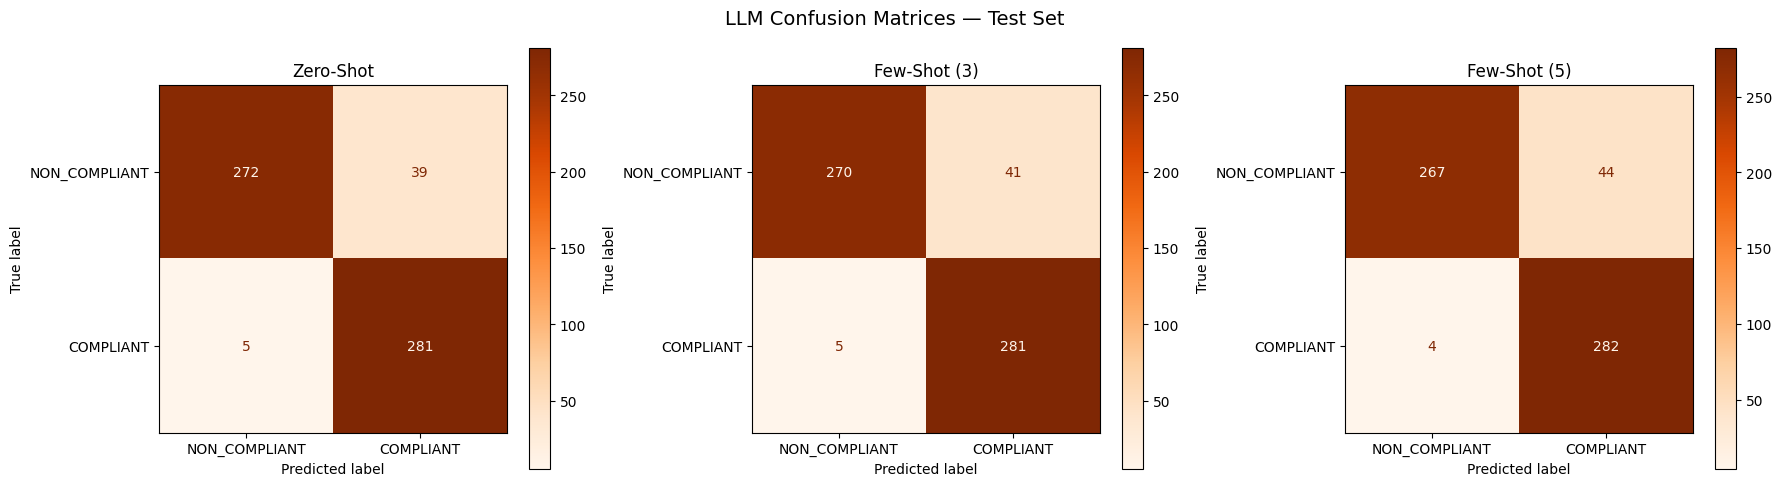

In [16]:
# Stage 9: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_names = ['NON_COMPLIANT', 'COMPLIANT']

for ax, (name, rdf) in zip(axes, [('Zero-Shot', zs_df),
                                    ('Few-Shot (3)', fs3_df),
                                    ('Few-Shot (5)', fs5_df)]):
    valid = rdf[~rdf['parse_failed'] & rdf['pred_label'].isin([0, 1])]
    if len(valid) > 0:
        cm = confusion_matrix(valid['true_label'], valid['pred_label'])
        disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
        disp.plot(ax=ax, cmap='Oranges', values_format='d')
    ax.set_title(name)

plt.suptitle('LLM Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

Stage 10: Per-Control Breakdown (Best LLM Condition)

PER-CONTROL BREAKDOWN — Zero-Shot
                              N      F1  Accuracy
Control                                          
CE1_Firewalls                65  0.8241    0.8462
CE2_SecureConfig             65  0.9212    0.9231
CE3_Patching                 39  1.0000    1.0000
CE4_AccessControl            52  1.0000    1.0000
CE5_Malware                  38  0.8869    0.8947
DSPT10_Suppliers             26  1.0000    1.0000
DSPT1_ConfidentialData       26  1.0000    1.0000
DSPT2_StaffResponsibilities  26  0.8831    0.8846
DSPT3_Training               52  1.0000    1.0000
DSPT4_DataAccess             39  0.6658    0.6667
DSPT5_ProcessReviews         26  1.0000    1.0000
DSPT6_Incidents              26  1.0000    1.0000
DSPT7_Continuity             39  0.9706    0.9744
DSPT8_UnsupportedSystems     39  0.9150    0.9231
DSPT9_ITProtection           39  0.8662    0.8718


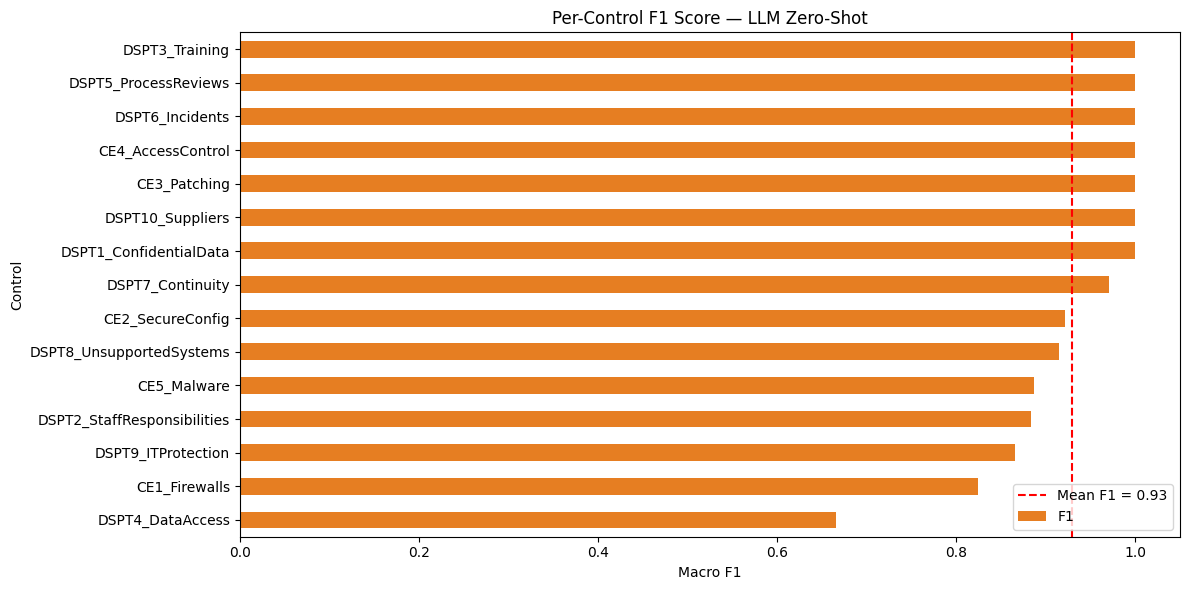

In [17]:
# Stage 10: Per-control F1 for best LLM condition
best_df_map = {'Zero-Shot': zs_df, 'Few-Shot (3 examples)': fs3_df, 'Few-Shot (5 examples)': fs5_df}
best_llm_df = best_df_map[best_llm]
valid = best_llm_df[~best_llm_df['parse_failed'] & best_llm_df['pred_label'].isin([0, 1])]

controls = sorted(valid['control'].unique())
per_control = []

for ctrl in controls:
    mask = valid['control'] == ctrl
    y_c = valid.loc[mask, 'true_label'].values
    p_c = valid.loc[mask, 'pred_label'].values

    if len(set(y_c)) < 2:
        f1 = np.nan
    else:
        f1 = f1_score(y_c, p_c, average='macro')

    per_control.append({
        'Control': ctrl,
        'N': len(y_c),
        'F1': f1,
        'Accuracy': accuracy_score(y_c, p_c),
    })

pc_llm = pd.DataFrame(per_control).set_index('Control')
print(f'PER-CONTROL BREAKDOWN — {best_llm}')
print('='*60)
print(pc_llm.round(4).to_string())

plt.figure(figsize=(12, 6))
pc_llm['F1'].sort_values().plot.barh(color='#e67e22')
plt.axvline(x=pc_llm['F1'].mean(), color='red', linestyle='--',
            label=f'Mean F1 = {pc_llm["F1"].mean():.2f}')
plt.title(f'Per-Control F1 Score — LLM {best_llm}')
plt.xlabel('Macro F1')
plt.legend()
plt.tight_layout()
plt.show()

Stage 11: False Positive Analysis and Hallucination Check

In [18]:
# Stage 11a: False positive analysis (best LLM condition)
valid = best_llm_df[~best_llm_df['parse_failed'] & best_llm_df['pred_label'].isin([0, 1])].copy()

fp = valid[(valid['true_label'] == 0) & (valid['pred_label'] == 1)]
fn = valid[(valid['true_label'] == 1) & (valid['pred_label'] == 0)]

total_nc = (valid['true_label'] == 0).sum()
total_c  = (valid['true_label'] == 1).sum()

print('DEPLOYMENT RISK ANALYSIS — LLM')
print('='*60)
print(f'False positives (dangerous — missed non-compliance): {len(fp)}/{total_nc} ({len(fp)/total_nc*100:.1f}%)')
print(f'False negatives (unnecessary review):                {len(fn)}/{total_c} ({len(fn)/total_c*100:.1f}%)')

if len(fp) > 0:
    print(f'\nFALSE POSITIVE SENTENCES (first 20):')
    print('-'*60)
    for r in fp.head(20).itertuples():
        print(f'  [{r.control}] {r.sentence_text}')
        print(f'    LLM reason: {r.reason}')
    print(f'\nPer-control false positive distribution:')
    print(fp['control'].value_counts().to_string())

DEPLOYMENT RISK ANALYSIS — LLM
False positives (dangerous — missed non-compliance): 39/311 (12.5%)
False negatives (unnecessary review):                5/286 (1.7%)

FALSE POSITIVE SENTENCES (first 20):
------------------------------------------------------------
  [CE1_Firewalls] Staff laptops used away from the home must be configured to have a firewall enabled at all times.
    LLM reason: The statement describes a practice that meets the requirement of having a firewall enabled at all times.
  [CE1_Firewalls] All staff laptops used outside the care home premises must have a firewall enabled.
    LLM reason: Enabling firewalls on staff laptops used outside the care home premises helps to secure the devices, which aligns with the requirement for a boundary firewall.
  [CE1_Firewalls] Laptops used by staff for personal use outside the home are not permitted without a firewall.
    LLM reason: The statement implies that laptops used in the care home have a firewall, which meets the req

In [19]:
# Stage 11b: Hallucination analysis
# Check LLM reasons for unsupported or fabricated justifications

print('HALLUCINATION ANALYSIS')
print('='*60)

# Parse failures = model couldn't even produce a valid classification
parse_fails = best_llm_df[best_llm_df['parse_failed']]
print(f'Parse failures (no valid label produced): {len(parse_fails)}')
if len(parse_fails) > 0:
    print('\nSample parse failures:')
    for r in parse_fails.head(5).itertuples():
        print(f'  Sentence: {r.sentence_text}')
        print(f'  Raw resp: {r.raw_response[:200]}')
        print()

# Wrong control assignment (LLM assigned a different control than ground truth)
valid_with_ctrl = valid[valid['pred_control'] != ''].copy()
if len(valid_with_ctrl) > 0:
    # Normalise control names for comparison
    valid_with_ctrl['ctrl_match'] = valid_with_ctrl.apply(
        lambda r: r['control'].lower().replace('_','') in r['pred_control'].lower().replace('_','') or
                  r['pred_control'].lower().replace('_','') in r['control'].lower().replace('_',''),
        axis=1)
    ctrl_accuracy = valid_with_ctrl['ctrl_match'].mean()
    print(f'\nControl mapping accuracy: {ctrl_accuracy:.1%} '
          f'({valid_with_ctrl["ctrl_match"].sum()}/{len(valid_with_ctrl)})')
    if ctrl_accuracy < 0.8:
        print('⚠ LLM frequently assigns the wrong control — reason text may be unreliable.')

# Correct label but fabricated reason (hardest to detect automatically)
print(f'\nManual hallucination check:')
print('Review 10 random correct predictions to verify reasons are grounded:')
correct = valid[valid['true_label'] == valid['pred_label']].sample(
    n=min(10, len(valid)), random_state=42)
for r in correct.itertuples():
    print(f'  [{"✓" if r.true_label==r.pred_label else "✗"}] {r.sentence_text}')
    print(f'      Reason: {r.reason}')
    print()

HALLUCINATION ANALYSIS
Parse failures (no valid label produced): 0

Control mapping accuracy: 67.3% (402/597)
⚠ LLM frequently assigns the wrong control — reason text may be unreliable.

Manual hallucination check:
Review 10 random correct predictions to verify reasons are grounded:
  [✓] All data processing agreements with software suppliers remain uninitiated.
      Reason: Data processing agreements with all suppliers are not initiated

  [✓] All software installed on our systems are recorded in our centralised IT management system.
      Reason: Software installed on systems is recorded, which implies defaults have been changed and unnecessary software removed.

  [✓] The use of an unsupported web browser to access the care system remains unacceptable.
      Reason: The use of an unsupported web browser is not compliant with the standard as it may pose security risks.

  [✓] All software installed on home computers is formally documented
      Reason: Documentation of installed sof

In [26]:
# Stage 11c: Quantify mandate-phrasing in false positives (diagnostic for dissertation)
import re

MODAL = re.compile(r'\b(must|should|shall|needs? to|ought to|is required to|are required to|'
                   r'has to|have to|cannot|can not|is not permitted|are not permitted|'
                   r'is not allowed|are not allowed|without prior|is mandatory|are mandatory)\b',
                   re.IGNORECASE)

valid = zs_df[~zs_df['parse_failed'] & zs_df['pred_label'].isin([0, 1])].copy()
fp = valid[(valid['true_label'] == 0) & (valid['pred_label'] == 1)].copy()

fp['is_mandate_phrased'] = fp['sentence_text'].str.contains(MODAL)
n_mandate = fp['is_mandate_phrased'].sum()
n_total = len(fp)

print('MANDATE-PHRASING DIAGNOSTIC — ZERO-SHOT FALSE POSITIVES')
print('='*60)
print(f'Total false positives          : {n_total}')
print(f'Mandate/policy-phrased         : {n_mandate} ({n_mandate/n_total*100:.1f}%)')
print(f'Other (genuine model error)    : {n_total - n_mandate} ({(n_total-n_mandate)/n_total*100:.1f}%)')

print(f'\n--- Mandate-phrased false positives ---')
for r in fp[fp['is_mandate_phrased']].itertuples():
    print(f'  [{r.control}] {r.sentence_text}')

print(f'\n--- Other false positives (genuine reasoning gaps) ---')
for r in fp[~fp['is_mandate_phrased']].itertuples():
    print(f'  [{r.control}] {r.sentence_text}')

# Per-control breakdown of the mandate pattern
print(f'\n--- Mandate-phrased FPs by control ---')
print(fp[fp['is_mandate_phrased']]['control'].value_counts().to_string())

fp.to_csv('fp_mandate_diagnostic.csv', index=False)
print(f'\nSaved -> fp_mandate_diagnostic.csv')

MANDATE-PHRASING DIAGNOSTIC — ZERO-SHOT FALSE POSITIVES
Total false positives          : 39
Mandate/policy-phrased         : 29 (74.4%)
Other (genuine model error)    : 10 (25.6%)

--- Mandate-phrased false positives ---
  [CE1_Firewalls] Staff laptops used away from the home must be configured to have a firewall enabled at all times.
  [CE1_Firewalls] All staff laptops used outside the care home premises must have a firewall enabled.
  [CE1_Firewalls] Laptops used by staff for personal use outside the home are not permitted without a firewall.
  [CE1_Firewalls] Firewalls must be enabled on all staff laptops when used away from the home premises.
  [CE2_SecureConfig] All USB devices must be detected and added to the system immediately upon being inserted.
  [CE2_SecureConfig] No USB device can be left unchecked once inserted; the system must automatically recognise and integrate it.
  [CE2_SecureConfig] USB devices must be immediately detected and incorporated into the system upon bein

Stage 12: Head-to-Head Comparison; ML vs LLM

In [20]:
# Stage 12a: Upload supervised ML results
print('Upload test_results.csv from the Supervised ML notebook.')
uploaded = files.upload()

Upload test_results.csv from the Supervised ML notebook.


Saving test_results.csv to test_results.csv


In [22]:
# Stage 12b: Build the final comparison table
sup_results = pd.read_csv('test_results.csv', index_col=0)

# Combine supervised + LLM results
all_results = pd.concat([
    sup_results,
    llm_results[['Accuracy', 'Precision', 'Recall', 'F1 (macro)']]
])

# Sort by F1
all_results = all_results.sort_values('F1 (macro)', ascending=False)

print('='*70)
print('FINAL COMPARISON — SUPERVISED ML vs LLM')
print('='*70)
print(all_results.round(4).to_string())
print()

overall_best = all_results['F1 (macro)'].idxmax()
print(f'Overall best: {overall_best} (F1 = {all_results.loc[overall_best, "F1 (macro)"]:.4f})')
print()

FINAL COMPARISON — SUPERVISED ML vs LLM
                       Accuracy  Precision  Recall  F1 (macro)
Zero-Shot                0.9263     0.9300  0.9286      0.9263
Few-Shot (3 examples)    0.9229     0.9272  0.9253      0.9229
Few-Shot (5 examples)    0.9196     0.9251  0.9223      0.9195
Random Forest            0.8727     0.8724  0.8726      0.8725
XGBoost                  0.8526     0.8524  0.8529      0.8525
Logistic Regression      0.8392     0.8391  0.8386      0.8388

Overall best: Zero-Shot (F1 = 0.9263)



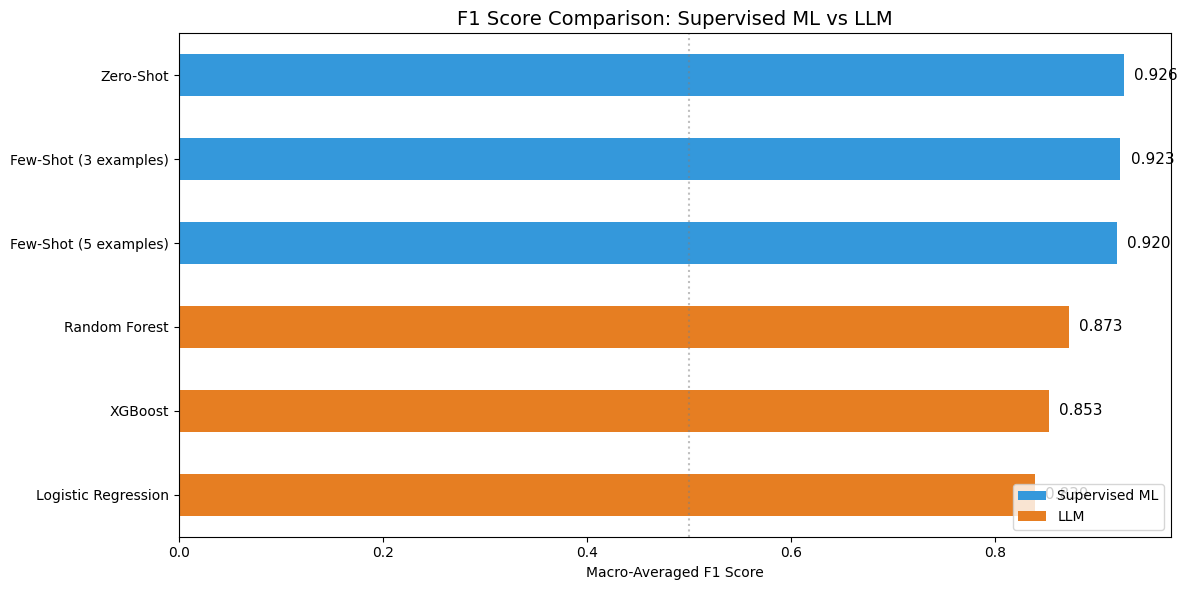

In [24]:
# Stage 12c: Visualise the comparison
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db' if 'Shot' not in idx else '#e67e22' for idx in all_results.index]
all_results['F1 (macro)'].sort_values().plot.barh(ax=ax, color=colors)

ax.set_title('F1 Score Comparison: Supervised ML vs LLM', fontsize=14)
ax.set_xlabel('Macro-Averaged F1 Score')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')

# Add value labels
for i, (idx, val) in enumerate(all_results['F1 (macro)'].sort_values().items()):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Supervised ML'),
                   Patch(facecolor='#e67e22', label='LLM')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

Stage 13: Saving All Results

In [25]:
# Stage 13: Save everything

# LLM predictions with reasons (for dissertation appendix / discussion)
zs_df.to_csv('llm_zero_shot_predictions.csv', index=False)
fs3_df.to_csv('llm_few_shot_3_predictions.csv', index=False)
fs5_df.to_csv('llm_few_shot_5_predictions.csv', index=False)

# Comparison table
all_results.round(4).to_csv('final_comparison_results.csv')

# Per-control LLM results
pc_llm.round(4).to_csv('llm_per_control_results.csv')

print('Saved:')
print('  llm_zero_shot_predictions.csv')
print('  llm_few_shot_3_predictions.csv')
print('  llm_few_shot_5_predictions.csv')
print('  final_comparison_results.csv')
print('  llm_per_control_results.csv')
print()

# Download
from google.colab import files
for f in ['llm_zero_shot_predictions.csv', 'llm_few_shot_3_predictions.csv',
          'llm_few_shot_5_predictions.csv', 'final_comparison_results.csv',
          'llm_per_control_results.csv']:
    files.download(f)

Saved:
  llm_zero_shot_predictions.csv
  llm_few_shot_3_predictions.csv
  llm_few_shot_5_predictions.csv
  final_comparison_results.csv
  llm_per_control_results.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>